# Notebook 06: Baseline Modeling and Diagnostics

**Project:** NFL Wide Receiver Performance and Contract Value Analysis  
**Authors:** William Reed and Jason Kuzmission  
**Primary Notebook Developer:** William Reed  

## Purpose

This notebook establishes and evaluates the baseline models used to predict
next-season NFL wide receiver receiving yards.

The analysis uses the finalized modeling dataset produced during preprocessing
and preserves the player grouped validation strategy established earlier in the
project. Grouping by player prevents observations from the same player from
appearing in both training and testing data, reducing the risk of data leakage.

In [17]:
from pathlib import Path

import polars as pl
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GroupShuffleSplit, GroupKFold, cross_validate
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import jarque_bera

In [18]:
# Load the finalized modeling dataset
data_path = Path("../data/processed/wr_model.csv")

wr_model = pl.read_csv(data_path)

print(f"Dataset shape: {wr_model.shape}")
print(f"Rows: {wr_model.height:,}")
print(f"Columns: {wr_model.width}")

required_columns = [
    "player_id",
    "receiving_yards",
    "next_season_receiving_yards"
]

for column in required_columns:
    print(f"{column}: {column in wr_model.columns}")

Dataset shape: (2129, 139)
Rows: 2,129
Columns: 139
player_id: True
receiving_yards: True
next_season_receiving_yards: True


## Baseline Data Verification

Before creating the training and testing sets, the player structure and variables required for the baseline analysis are checked for missing values. This confirms that the historical baseline and validation procedure use complete observations from the finalized modeling dataset.

In [19]:
# Verify player structure and baseline variables

unique_players = wr_model.select(
    pl.col("player_id").n_unique()
).item()

missing_check = wr_model.select([
    pl.col("player_id").null_count().alias("player_id_missing"),
    pl.col("receiving_yards").null_count().alias("receiving_yards_missing"),
    pl.col("next_season_receiving_yards").null_count().alias(
        "target_missing"
    )
])

print(f"Unique players: {unique_players}")
print("\nMissing values:")
print(missing_check)

Unique players: 620

Missing values:
shape: (1, 3)
┌───────────────────┬─────────────────────────┬────────────────┐
│ player_id_missing ┆ receiving_yards_missing ┆ target_missing │
│ ---               ┆ ---                     ┆ ---            │
│ u32               ┆ u32                     ┆ u32            │
╞═══════════════════╪═════════════════════════╪════════════════╡
│ 0                 ┆ 0                       ┆ 0              │
└───────────────────┴─────────────────────────┴────────────────┘


## Grouped Train and Test Split

The data are divided into training and testing sets by player rather than by individual player season observations. This ensures that all seasons belonging to the same player remain entirely within either the training set or the testing set.

A grouped split is used because the dataset contains repeated observations for many players across multiple seasons. A standard random row split could place different seasons from the same player in both sets, creating player level information leakage and producing overly optimistic estimates of model performance.

In [20]:
# Create grouped train/test split by player

groups = wr_model["player_id"].to_numpy()

group_split = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    group_split.split(wr_model, groups=groups)
)

train_data = wr_model[train_idx]
test_data = wr_model[test_idx]

train_players = set(train_data["player_id"].to_list())
test_players = set(test_data["player_id"].to_list())

player_overlap = train_players.intersection(test_players)

print(f"Training observations: {train_data.height:,}")
print(f"Testing observations: {test_data.height:,}")
print(f"Training players: {len(train_players)}")
print(f"Testing players: {len(test_players)}")
print(f"Player overlap: {len(player_overlap)}")

Training observations: 1,686
Testing observations: 443
Training players: 496
Testing players: 124
Player overlap: 0


## Historical Persistence Baseline

The primary baseline uses a player's current season receiving yards as the prediction for his next season receiving yards.

This baseline represents a simple assumption that a player's receiving production will remain unchanged from one season to the next. It provides a practical benchmark for determining whether a fitted statistical or machine learning model adds predictive value beyond the player's most recent production.

Predicted next season receiving yards = Current season receiving yards

In [21]:
# Historical persistence baseline on the held-out test set

y_test = test_data["next_season_receiving_yards"].to_numpy()
persistence_predictions = test_data["receiving_yards"].to_numpy()

persistence_mae = mean_absolute_error(
    y_test,
    persistence_predictions
)

persistence_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        persistence_predictions
    )
)

persistence_r2 = r2_score(
    y_test,
    persistence_predictions
)

print("Historical Persistence Baseline")
print(f"MAE: {persistence_mae:.2f}")
print(f"RMSE: {persistence_rmse:.2f}")
print(f"R-squared: {persistence_r2:.3f}")

Historical Persistence Baseline
MAE: 232.32
RMSE: 323.76
R-squared: 0.421


### Predictor and Target Definition

The finalized modeling dataset contains **139 total columns** and **2,129 player-season observations**.

For baseline model development, next_season_receiving_yards is used as the prediction target, while Player_id is retained only as the grouping variable used to prevent the same player from appearing in both the training and test sets.

Three variables identified during feature preparation are excluded because of excessive missingness:

- `passing_cpoe`
- `passing_epa`
- `pacr`

After excluding the player identifier, prediction target, and these three high missingness variables, **134 predictor variables** remain for baseline model fitting.

In [22]:
# Define predictors, target, grouping variable, and excluded features

target_column = "next_season_receiving_yards"
group_column = "player_id"

features_to_drop = [
    "passing_cpoe",
    "passing_epa",
    "pacr"
]

predictor_columns = [
    column
    for column in wr_model.columns
    if column not in [
        target_column,
        group_column,
        *features_to_drop
    ]
]

print(f"Predictor variables: {len(predictor_columns)}")
print(f"Target: {target_column}")
print(f"Grouping variable: {group_column}")

print("\nExcluded high-missingness predictors:")
for feature in features_to_drop:
    print(f"• {feature}")

assert len(predictor_columns) == 134, (
    f"Expected 134 predictors, found {len(predictor_columns)}."
)

assert target_column not in predictor_columns
assert group_column not in predictor_columns

for feature in features_to_drop:
    assert feature not in predictor_columns

print("\nPredictor definition verified.")

Predictor variables: 134
Target: next_season_receiving_yards
Grouping variable: player_id

Excluded high-missingness predictors:
• passing_cpoe
• passing_epa
• pacr

Predictor definition verified.


### Prepare Modeling Matrices

The **134 finalized predictor variables** are separated from the target variable for model fitting.

The predictor matrix `X` contains only the features approved for modeling, while `y` contains next_season_receiving_yards. Player identifiers are stored separately as the grouping variable and are not included as model predictors.

Keeping the grouping variable separate allows the subsequent train/test split to be performed at the player level, preventing observations from the same player from appearing in both datasets and reducing the risk of information leakage across the evaluation boundary.

In [23]:
# Prepare training and testing matrices

X_train = train_data.select(predictor_columns)
X_test = test_data.select(predictor_columns)

y_train = train_data[target_column].to_numpy()
y_test = test_data[target_column].to_numpy()

# Check predictor data types
non_numeric_columns = [
    col
    for col, dtype in X_train.schema.items()
    if not dtype.is_numeric()
]

# Check missing values
train_nulls = X_train.null_count().sum_horizontal().sum()
test_nulls = X_test.null_count().sum_horizontal().sum()

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train observations: {len(y_train):,}")
print(f"y_test observations: {len(y_test):,}")
print(f"Non-numeric predictors: {len(non_numeric_columns)}")
print(f"Training missing values: {train_nulls}")
print(f"Testing missing values: {test_nulls}")

if non_numeric_columns:
    print("\nNon-numeric columns:")
    print(non_numeric_columns)

X_train shape: (1686, 134)
X_test shape: (443, 134)
y_train observations: 1,686
y_test observations: 443
Non-numeric predictors: 0
Training missing values: 3062
Testing missing values: 656


## Missing Data Treatment

Missing predictor values are imputed using medians calculated from the training data only. The resulting training medians are then applied to both the training and held out testing sets.

Calculating imputation values from the training data prevents information from the held out test set from influencing model development. Median imputation is retained from the preprocessing plan because it is less sensitive to extreme values than mean imputation.

In [24]:
# Calculate predictor medians using training data only

train_medians = X_train.select(
    [
        pl.col(column).median().alias(column)
        for column in predictor_columns
    ]
)

# Convert the single-row median table to a dictionary
median_values = train_medians.row(0, named=True)

# Apply training-derived medians to both datasets
X_train_imputed = X_train.with_columns(
    [
        pl.col(column).fill_null(median_values[column])
        for column in predictor_columns
    ]
)

X_test_imputed = X_test.with_columns(
    [
        pl.col(column).fill_null(median_values[column])
        for column in predictor_columns
    ]
)

# Verify imputation
train_nulls_after = (
    X_train_imputed.null_count()
    .sum_horizontal()
    .sum()
)

test_nulls_after = (
    X_test_imputed.null_count()
    .sum_horizontal()
    .sum()
)

print(f"Training missing values before: {train_nulls}")
print(f"Training missing values after: {train_nulls_after}")
print(f"Testing missing values before: {test_nulls}")
print(f"Testing missing values after: {test_nulls_after}")

Training missing values before: 3062
Training missing values after: 0
Testing missing values before: 656
Testing missing values after: 0


## Initial Linear Regression Model

Multiple linear regression was used as the primary baseline model for predicting next season receiving yards. It was selected because it provides an interpretable benchmark for determining whether the full set of player performance variables improves prediction compared with using previous season receiving yards alone.

The general multiple linear regression model is:

The model was trained using the player grouped training set and evaluated on the held out testing set. MAE, RMSE, and R-squared were used to evaluate predictive performance. Training and testing performance were also compared to assess possible overfitting.

In [25]:
# Convert imputed Polars DataFrames to NumPy arrays

X_train_np = X_train_imputed.to_numpy()
X_test_np = X_test_imputed.to_numpy()

# Fit ordinary least squares linear regression

linear_model = LinearRegression()

linear_model.fit(
    X_train_np,
    y_train
)

# Generate predictions

linear_predictions = linear_model.predict(X_test_np)

# Evaluate held-out test performance

linear_mae = mean_absolute_error(
    y_test,
    linear_predictions
)

linear_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        linear_predictions
    )
)

linear_r2 = r2_score(
    y_test,
    linear_predictions
)

print("Linear Regression Performance")
print(f"MAE: {linear_mae:.2f}")
print(f"RMSE: {linear_rmse:.2f}")
print(f"R-squared: {linear_r2:.3f}")

Linear Regression Performance
MAE: 224.57
RMSE: 304.43
R-squared: 0.488


## Training and Testing Performance

To evaluate possible overfitting, the fitted linear regression model is evaluated on both the training and held-out testing datasets. A substantial difference between training and testing performance may indicate that the model is fitting patterns in the training data that do not generalize as well to unseen players.

These results provide an initial assessment of generalization before grouped cross-validation and regression diagnostics are performed.

In [26]:
# Evaluate linear regression on training data

train_predictions = linear_model.predict(X_train_np)

train_mae = mean_absolute_error(
    y_train,
    train_predictions
)

train_rmse = np.sqrt(
    mean_squared_error(
        y_train,
        train_predictions
    )
)

train_r2 = r2_score(
    y_train,
    train_predictions
)

print("Linear Regression: Training vs Testing")
print()
print("Training Performance")
print(f"MAE: {train_mae:.2f}")
print(f"RMSE: {train_rmse:.2f}")
print(f"R-squared: {train_r2:.3f}")

print()
print("Testing Performance")
print(f"MAE: {linear_mae:.2f}")
print(f"RMSE: {linear_rmse:.2f}")
print(f"R-squared: {linear_r2:.3f}")

Linear Regression: Training vs Testing

Training Performance
MAE: 195.37
RMSE: 255.70
R-squared: 0.581

Testing Performance
MAE: 224.57
RMSE: 304.43
R-squared: 0.488


## Grouped Cross-Validation

Five fold grouped cross validation is used to evaluate how consistently the linear regression model generalizes across different groups of NFL wide receivers.

Player ID is used as the grouping variable so that observations from the same player cannot appear in both the training and validation portions of a fold. This preserves the longitudinal structure of the dataset and reduces the risk of player level information leakage.

Cross-validation performance is evaluated using MAE, RMSE, and R-squared.

In [27]:
# Leakage-safe five-fold grouped cross-validation

groups_train = train_data[group_column].to_numpy()

# Use the original predictor data with missing values.
# Imputation will now occur separately inside each CV fold.
X_train_raw = X_train.to_numpy()

group_cv = GroupKFold(n_splits=5)

cv_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", LinearRegression())
])

cv_mae = []
cv_rmse = []
cv_r2 = []

for fold, (cv_train_idx, cv_val_idx) in enumerate(
    group_cv.split(X_train_raw, y_train, groups=groups_train),
    start=1
):
    X_cv_train = X_train_raw[cv_train_idx]
    X_cv_val = X_train_raw[cv_val_idx]

    y_cv_train = y_train[cv_train_idx]
    y_cv_val = y_train[cv_val_idx]

    cv_pipeline.fit(X_cv_train, y_cv_train)
    cv_predictions = cv_pipeline.predict(X_cv_val)

    fold_mae = mean_absolute_error(y_cv_val, cv_predictions)
    fold_rmse = np.sqrt(
        mean_squared_error(y_cv_val, cv_predictions)
    )
    fold_r2 = r2_score(y_cv_val, cv_predictions)

    cv_mae.append(fold_mae)
    cv_rmse.append(fold_rmse)
    cv_r2.append(fold_r2)

    print(
        f"Fold {fold}: "
        f"MAE={fold_mae:.2f}, "
        f"RMSE={fold_rmse:.2f}, "
        f"R²={fold_r2:.3f}"
    )

print()
print("Leakage-Safe 5-Fold Grouped Cross-Validation")
print(f"Mean MAE: {np.mean(cv_mae):.2f}")
print(f"Mean RMSE: {np.mean(cv_rmse):.2f}")
print(f"Mean R-squared: {np.mean(cv_r2):.3f}")
print(f"R-squared SD: {np.std(cv_r2):.3f}")

Fold 1: MAE=219.00, RMSE=283.39, R²=0.485
Fold 2: MAE=209.67, RMSE=275.78, R²=0.528
Fold 3: MAE=217.29, RMSE=275.22, R²=0.517
Fold 4: MAE=210.64, RMSE=278.70, R²=0.550
Fold 5: MAE=190.77, RMSE=249.19, R²=0.517

Leakage-Safe 5-Fold Grouped Cross-Validation
Mean MAE: 209.47
Mean RMSE: 272.46
Mean R-squared: 0.519
R-squared SD: 0.021


## Linear Regression Assumption Diagnostics

The assumptions and behavior of the ordinary least squares baseline are evaluated using residual diagnostics and other statistical checks. Particular attention is given to linearity, constant residual variance, residual distribution, dependence among observations, and multicollinearity among predictors.

Because the primary purpose of the model is prediction, these diagnostics are used to identify limitations in the linear baseline and to help determine whether more flexible or regularized models should be considered in the next stage of the analysis.

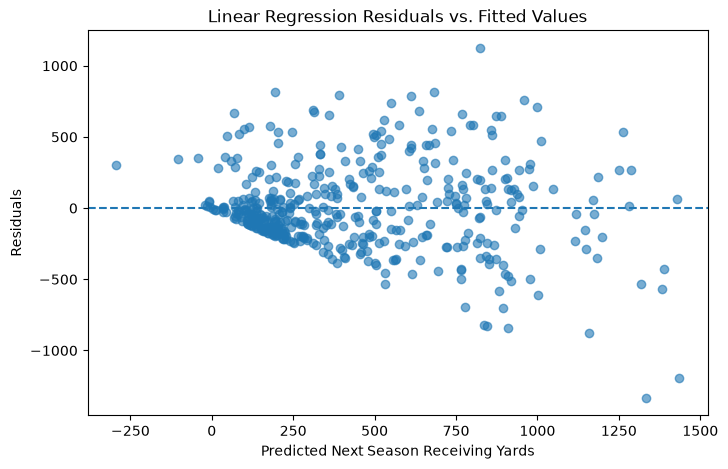

In [28]:
# Calculate held-out test residuals

test_residuals = y_test - linear_predictions

# Residuals versus fitted values

plt.figure(figsize=(8, 5))

plt.scatter(
    linear_predictions,
    test_residuals,
    alpha=0.6
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Next Season Receiving Yards")
plt.ylabel("Residuals")
plt.title("Linear Regression Residuals vs. Fitted Values")

plt.show()

**Figure 1. Linear Regression Residuals vs. Fitted Values.**  
The residual plot shows increasing variability as predicted next season receiving yards increase. Residuals are relatively concentrated at lower fitted values but become more dispersed for higher predicted production, producing a visible fan shaped pattern. This suggests that the constant variance (homoscedasticity) assumption of ordinary least squares may be violated. Several large residuals are also present among higher predicted values, indicating that prediction error is greater for some high production receivers. The residual structure will be examined with additional diagnostics before drawing conclusions about the adequacy of the linear model.

### Residual Error Across the Production Range

Receiving yards are a continuous and right skewed target, with relatively few player seasons representing very high receiving production. This distribution makes it important to examine where prediction errors occur rather than relying only on overall model performance metrics.

The residual plot shows that errors become more dispersed as predicted receiving yards increase, including several large errors among higher production receivers. This indicates that the linear regression baseline has greater difficulty predicting some less common, high production seasons.

This pattern is important to the project because large prediction errors can have a greater effect on downstream contract value assessments than smaller errors near the center of the production distribution. For that reason, MAE is used to measure typical prediction error, while RMSE provides additional information by placing greater weight on large misses. Residual diagnostics are used alongside both metrics to identify where model performance is weakest.

## Breusch-Pagan Test for Heteroscedasticity

The residual plot suggests that prediction errors may have non constant variance. 
A Breusch-Pagan test is used to formally evaluate whether the variance of the 
residuals changes systematically with the model's fitted values.

The null hypothesis is that the residual variance is constant (homoscedasticity).
A small p-value provides evidence against this assumption.

In [29]:
# Breusch-Pagan test for heteroscedasticity

bp_exog = sm.add_constant(linear_predictions)

bp_test = het_breuschpagan(
    test_residuals,
    bp_exog
)

bp_labels = [
    "LM Statistic",
    "LM p-value",
    "F Statistic",
    "F p-value"
]

print("Breusch-Pagan Test")
for label, value in zip(bp_labels, bp_test):
    print(f"{label}: {value:.6f}")

Breusch-Pagan Test
LM Statistic: 59.878224
LM p-value: 0.000000
F Statistic: 68.924030
F p-value: 0.000000


### Breusch-Pagan Test Interpretation

The Breusch-Pagan test provided evidence of heteroscedasticity in the linear regression residuals (LM = 59.88, p < .001; F = 68.92, p < .001). Therefore, the null hypothesis of constant residual variance was rejected.

This result supports the pattern observed in the residual plot, where prediction errors become more variable as predicted receiving production increases.

### Residual Normality Interpretation

The Jarque-Bera test indicated that the linear regression residuals were not normally distributed (JB = 53.05, p < .001).

Residual skewness was 0.133 and kurtosis was 4.674. The small positive skew indicates limited asymmetry, while the elevated kurtosis indicates heavier tails than expected under a normal distribution.

The normality assumption is not fully satisfied.

In [30]:
# Jarque-Bera test for residual normality

jb_stat, jb_pvalue, jb_skew, jb_kurtosis = jarque_bera(test_residuals)

print("Jarque-Bera Test")
print(f"JB Statistic: {jb_stat:.6f}")
print(f"JB p-value: {jb_pvalue:.6f}")
print(f"Skewness: {jb_skew:.3f}")
print(f"Kurtosis: {jb_kurtosis:.3f}")

Jarque-Bera Test
JB Statistic: 53.046858
JB p-value: 0.000000
Skewness: 0.133
Kurtosis: 4.674


## Multicollinearity

Multicollinearity was identified during the earlier exploratory data analysis and preprocessing stages. The predictor set contains substantial correlation among opportunity, production, and efficiency measures, which can make individual ordinary least squares coefficient estimates unstable and difficult to interpret.

This issue was addressed in Notebook 05 using two feature reduction approaches. PCA reduced the 134 predictors to 46 principal components while retaining approximately 95 percent of the variance. Lasso regression retained 64 predictors and removed 70 through coefficient shrinkage.

The linear regression model retains all 134 predictors because its purpose is to provide a baseline for comparison with the feature reduction and regularized modeling approaches.

## Independence and Longitudinal Structure

The dataset contains multiple seasons for many of the same wide receivers, so player season observations cannot automatically be treated as completely independent. This structure was identified during preprocessing and was addressed by grouping observations by player ID during validation.

All seasons belonging to the same player were kept together in either the training or testing partition. Five fold GroupKFold cross validation was also performed using player ID as the grouping variable, preventing the same player from appearing in both the training and validation portions of a fold. This does not make repeated seasons statistically independent, but it reduces player level information leakage and provides a more appropriate assessment of model performance on unseen players.

## Baseline Model Performance Comparison

The historical persistence baseline and ordinary least squares linear regression are compared on the same held out test set. Lower MAE and RMSE indicate smaller prediction errors, while higher R squared indicates that the model explains more variation in next season receiving yards.

In [31]:
# Compare held-out baseline model performance

comparison_table = pl.DataFrame({
    "Model": [
        "Historical Persistence",
        "Linear Regression"
    ],
    "MAE": [
        persistence_mae,
        linear_mae
    ],
    "RMSE": [
        persistence_rmse,
        linear_rmse
    ],
    "R_squared": [
        persistence_r2,
        linear_r2
    ]
})

comparison_table

Model,MAE,RMSE,R_squared
str,f64,f64,f64
"""Historical Persistence""",232.322799,323.756294,0.420785
"""Linear Regression""",224.5719,304.426286,0.487885


### Baseline Performance Interpretation

On the held-out test set, linear regression outperformed the historical persistence baseline across all three evaluation metrics.

MAE decreased from 232.32 to 224.57 yards, while RMSE decreased from 323.76 to 304.43 yards. R-squared increased from 0.421 to 0.488.

These results indicate that the full predictor set provides additional predictive information beyond simply using a player's current season receiving yards as the prediction for the following season.

## Discussion and Next Steps

The baseline results show that multiple player performance variables improve prediction of next season receiving yards compared with using current season receiving yards alone. On the held out test set, linear regression reduced MAE from 232.32 to 224.57 yards and RMSE from 323.76 to 304.43 yards. R squared increased from 0.421 to 0.488.

Training performance was stronger than testing performance. Training R squared was 0.581 compared with 0.488 on the test set. Five fold grouped cross validation produced a mean R squared of 0.519 with a standard deviation of 0.021. Grouping by player prevented observations from the same receiver from appearing in both training and validation data.

The diagnostic results identified limitations of linear regression. The Breusch Pagan test found evidence of heteroscedasticity (LM = 59.88, p < .001), and the Jarque Bera test indicated that the residuals were not normally distributed (JB = 53.05, p < .001). Multicollinearity was also identified during the earlier EDA and preprocessing stages.

PCA and Lasso were previously evaluated to address the large number of correlated predictors. PCA reduced the 134 predictors to 46 principal components, while Lasso retained 64 predictors. The next modeling phase will evaluate nonlinear approaches, including Random Forest, using player grouped validation.

Models will continue to be compared using MAE, RMSE, and R squared. The final model will be selected based on predictive performance, generalization to unseen players, and usefulness for the NFL General Manager stakeholder.